### import data

In [8]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_score, accuracy_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.decomposition import PCA
import umap
import matplotlib.pyplot as plt

In [9]:
data = pd.read_csv('./data/train_processed.csv')
X = data.drop('Attrition', axis=1)
y = data['Attrition']

In [10]:
# check data balance
print(y.value_counts()/len(y))


1    0.524514
0    0.475486
Name: Attrition, dtype: float64


### plot the heatmap to check dataset's linearity

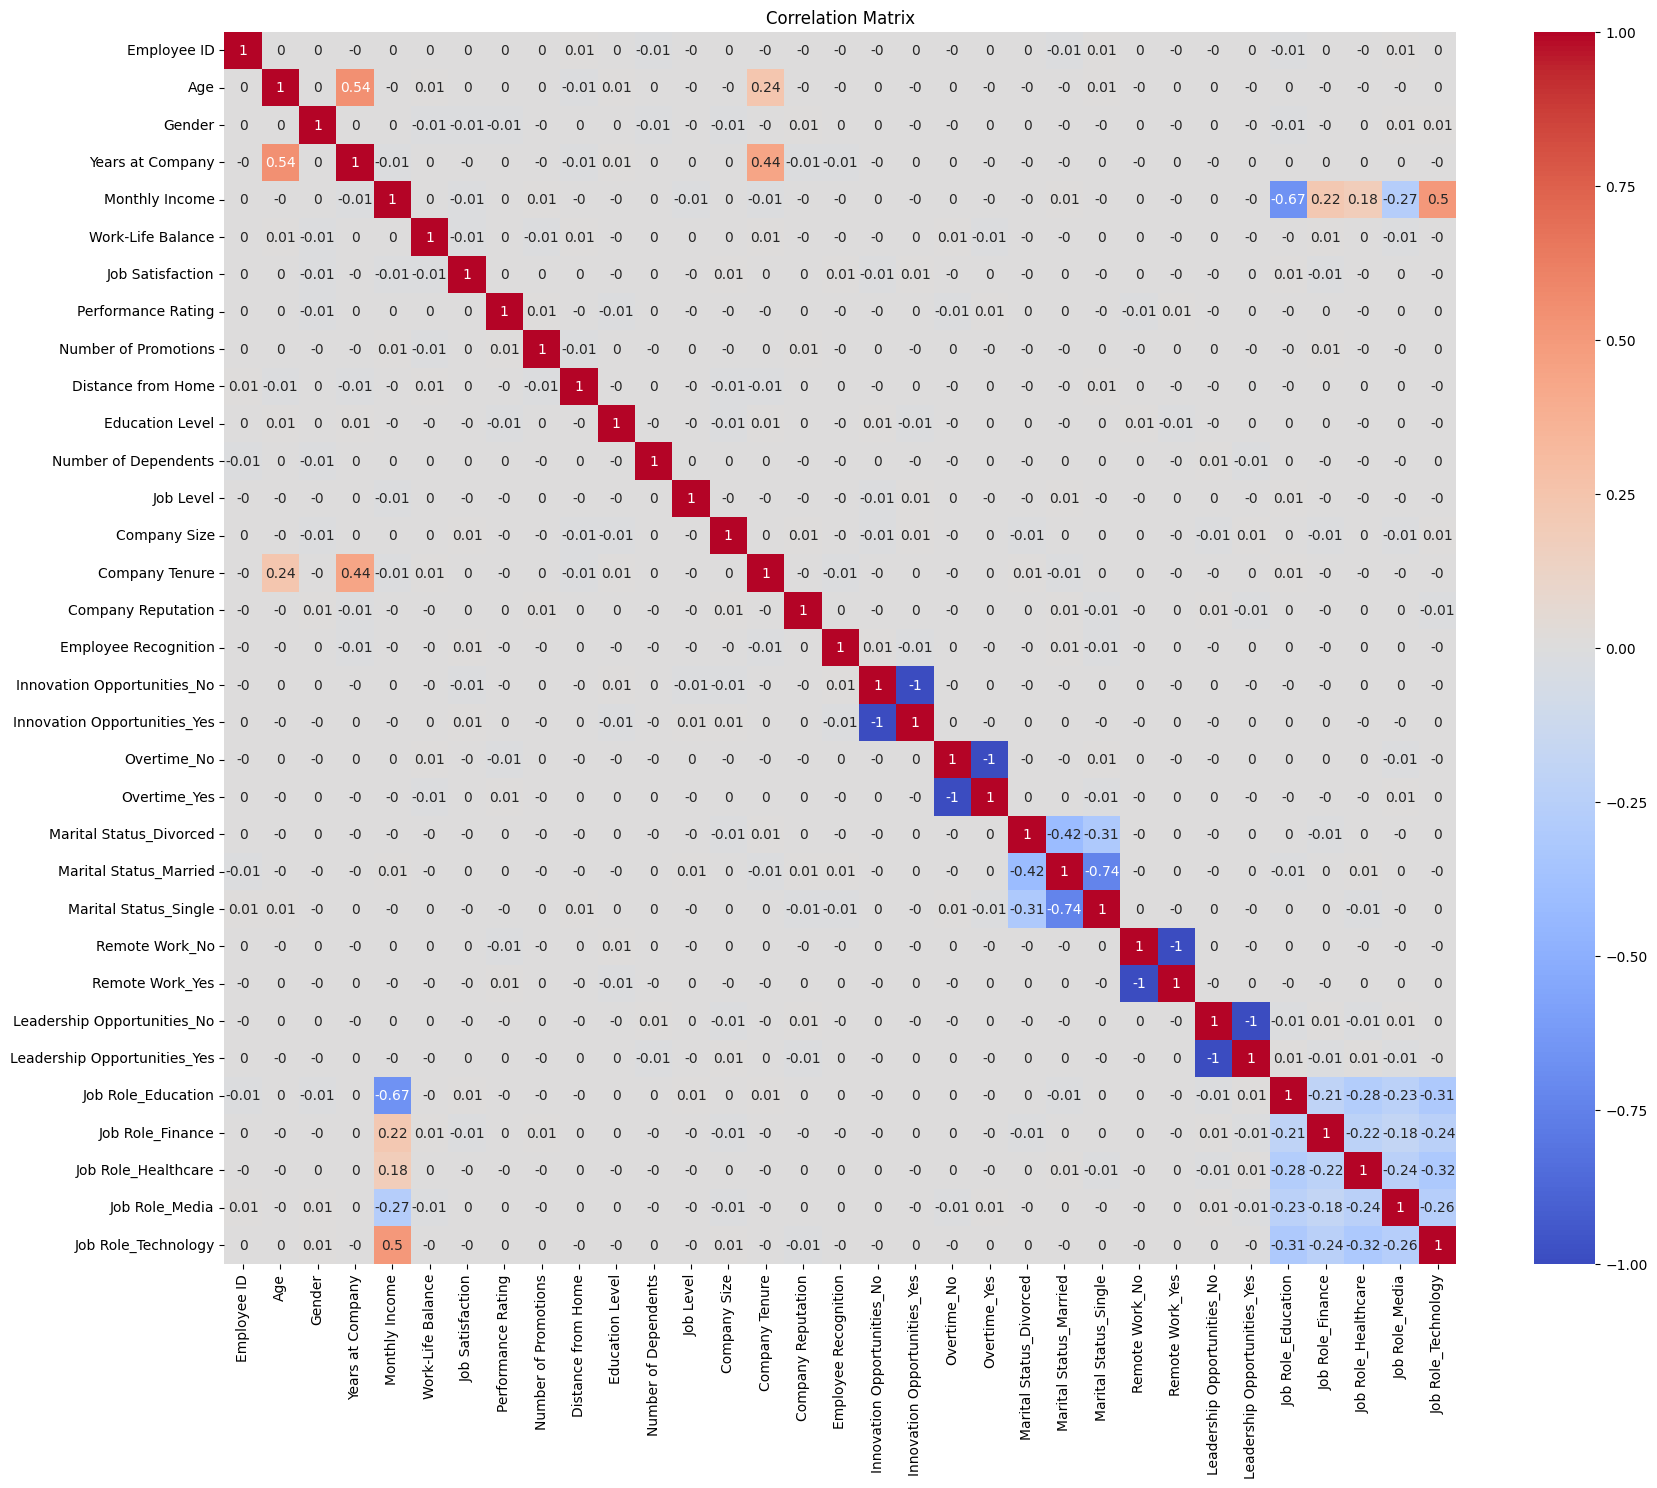

In [11]:
import seaborn as sns
correlation = X.corr().round(2)
plt.figure(figsize=(20, 16))
sns.heatmap(correlation, annot=True, cmap='coolwarm', square=True)
plt.title('Correlation Matrix')
plt.show()

doesn't seems linear, that could explains why data post pca seems to overlap while data post umap don't (doesn't explain the strange shape tho)

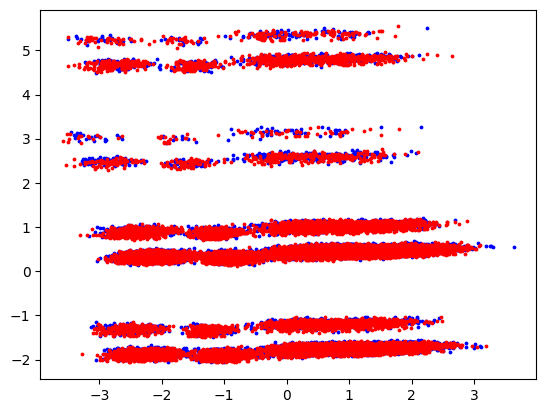

In [12]:
pca = PCA(n_components=2)
X_t= pd.DataFrame(pca.fit_transform(StandardScaler().fit_transform(X)))

plt.scatter(X_t.loc[y==0,0], X_t.loc[y==0,1], c='blue', s=3)
plt.scatter(X_t.loc[y==1,0], X_t.loc[y==1,1], c='red', s=3)
plt.show()

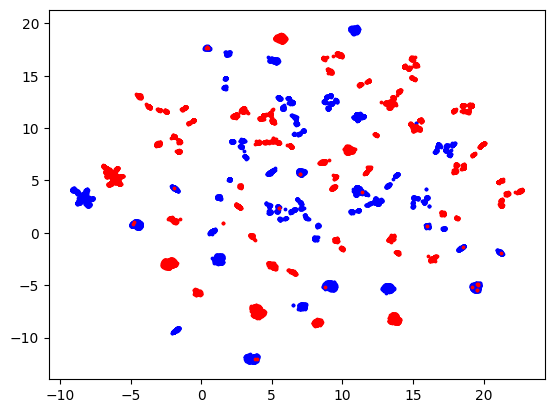

In [13]:
um = umap.UMAP(n_components=2)
X_t = pd.DataFrame(um.fit_transform(StandardScaler().fit_transform(X), y))

plt.scatter(X_t.loc[y==0,0], X_t.loc[y==0,1], c='blue', s=3)
plt.scatter(X_t.loc[y==1,0], X_t.loc[y==1,1], c='red', s=3)
plt.show()

explained variance of (0,1): 4.0833524952775875


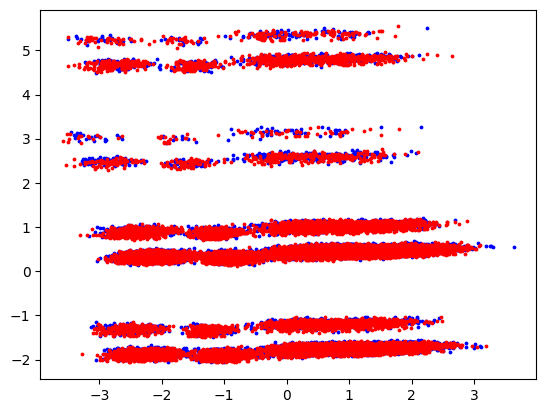

explained variance of (2,3): 4.002208476045077


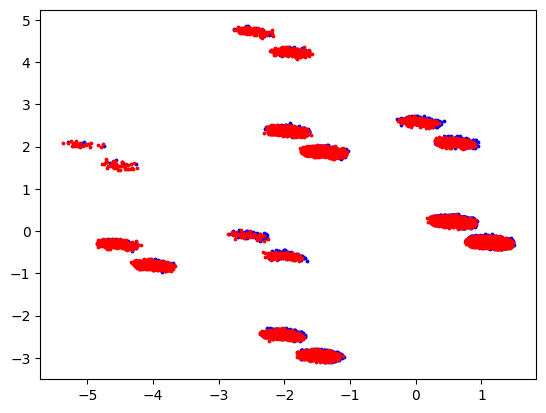

explained variance of (4,5): 3.820303808921061


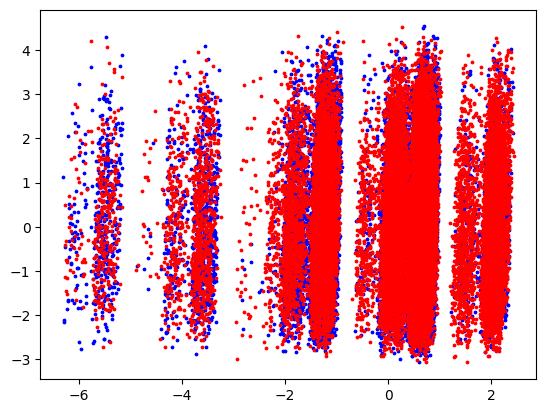

In [14]:
pca = PCA(n_components=6)
X_t = pca.fit_transform(StandardScaler().fit_transform(X))
for i in range(0, 6, 2):
    plt.scatter(X_t[y==0,i], X_t[y==0,i+1], c='blue', s=3)
    plt.scatter(X_t[y==1,i], X_t[y==1,i+1], c='red', s=3)
    print(f'explained variance of ({i},{i+1}): {pca.explained_variance_[i] + pca.explained_variance_[i+1]}')
    plt.show()

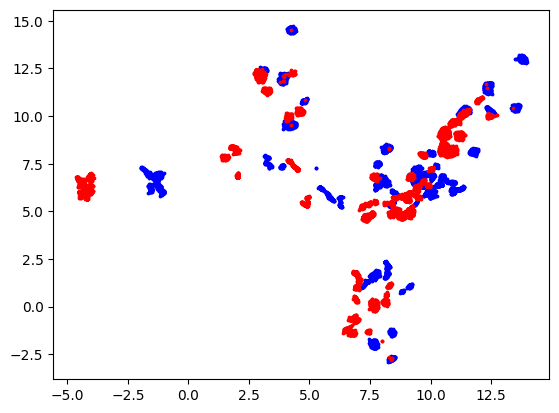

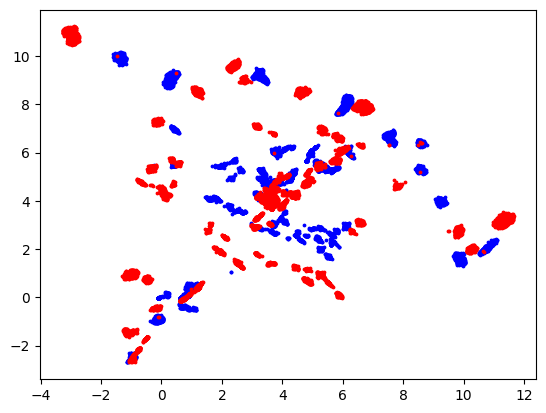

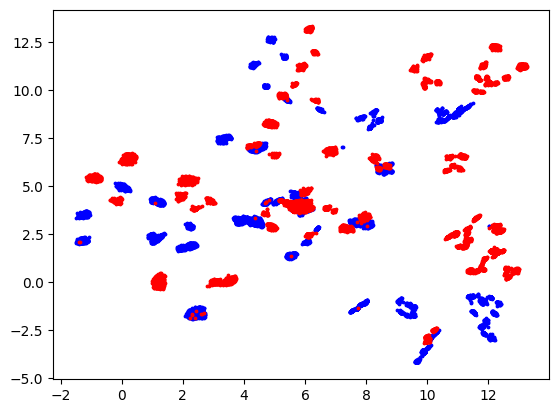

In [15]:

umap1 = umap.UMAP(n_components=6)
X_t = umap1.fit_transform(StandardScaler().fit_transform(X), y)
for i in range(0, 6, 2):
    plt.scatter(X_t[y==0,i], X_t[y==0,i+1], c='blue', s=3)
    plt.scatter(X_t[y==1,i], X_t[y==1,i+1], c='red', s=3)
    plt.show()

In [16]:
from sklearn.model_selection import KFold
# X_train, X_valid, Y_train, Y_valid= train_test_split(X, y, test_size=0.2, shuffle=True, random_state=420960)

def print_metrics(arr):
  df = pd.DataFrame((['train', arr[0, 0], arr[0, 1]], ['valid',arr[1, 0], arr[1, 1]]), columns=['set', 'accuracy', 'precision']) 
  display(df)

def calc_metrics(X_train, X_valid, y_train, y_valid, model):
  train_pred = model.predict(X_train)
  valid_pred = model.predict(X_valid)
  acc_train= accuracy_score(y_train, train_pred)
  acc_valid= accuracy_score(y_valid, valid_pred)
  prec_train= precision_score(y_train, train_pred)
  prec_valid= precision_score(y_valid, valid_pred)

  arr = [[acc_train, prec_train], [acc_valid, prec_valid]]
  return arr


def kfold(X, Y, model, splits, dim_reduction=None):
  kf = KFold(splits, random_state=420, shuffle=True)
  metrics = np.zeros((2, 2))
  for train_indices, valid_indices in kf.split(X, Y):

    X_train, X_valid, Y_train, Y_valid = [X.iloc[train_indices], X.iloc[valid_indices], Y[train_indices], Y[valid_indices]]

    sc = StandardScaler()
    X_train = sc.fit_transform(X_train)
    X_valid = sc.transform(X_valid)

    if dim_reduction != None:
      X_train = dim_reduction.fit_transform(X_train)
      X_valid = dim_reduction.transform(X_valid)
    model.fit(X_train, Y_train)
    metrics += calc_metrics(X_train, X_valid, Y_train, Y_valid, model)

  metrics /= splits   
  print(model, end="") 
  display(pd.DataFrame([['train', metrics[0,0], metrics[0,1]], ['validation', metrics[1,0], metrics[1,1]]], columns=['set', 'accuracy', 'precision']))
  return model


In [17]:
# finding optimal value for k

# param_grid = {'n_neighbors': np.arange(21, (int)(np.sqrt(X.shape[0])), 2)}
# knn = KNeighborsClassifier()
# from sklearn.model_selection import GridSearchCV
# grid_search = GridSearchCV(knn, param_grid, cv=5, n_jobs=-1)
# grid_search.fit(X_train, Y_train)
# print(grid_search.best_params_) # 207
k = 207

In [18]:
# finding optimal setting for ann hidden layer

# param_grid = {#'hidden_layer_sizes': [(8,), (16,), (32,), (64), (128,), (8, 8), (16, 16), (32, 32)]
#   'learning_rate_init': [0.0001, 0.001, 0.01, 0.1], 'alpha': [0.0001, 0.001, 0.01, 0.1]}
# ann = MLPClassifier(learning_rate='adaptive', max_iter=1000)
# from sklearn.model_selection import GridSearchCV
# grid_search = GridSearchCV(ann, param_grid, cv=5, n_jobs=-1)
# grid_search.fit(X_train, Y_train)
# print(grid_search.best_params_) # (32,) 

hidden_layer = (32,)
learning_rate_init = 0.001

In [19]:

# param_grid = {'alpha': [0.1, 0.01, 0.001, 0.0001]}
# ann = MLPClassifier(learning_rate='adaptive', max_iter=1000)
# from sklearn.model_selection import GridSearchCV
# grid_search = GridSearchCV(ann, param_grid, cv=5, n_jobs=-1)
# grid_search.fit(X_train, Y_train)
# print(grid_search.best_params_)
hidden_layer_t = (16,)
learning_rate_init_t = 0.01
alpha = 0.1

#### pre dimensionality reduction, no pen

In [20]:
folds = [4, 5, 6]

In [21]:
for i in folds:
  print(f'------------------------------------{i} folds------------------------------------')
  kfold(X, y, KNeighborsClassifier(n_neighbors=k), i)
  kfold(X, y, LogisticRegression(max_iter=1000), i)
  kfold(X, y, MLPClassifier(hidden_layer_sizes=hidden_layer, learning_rate='adaptive', max_iter=1000, alpha=0, learning_rate_init=learning_rate_init), i)

------------------------------------4 folds------------------------------------
KNeighborsClassifier(n_neighbors=207)

,set,accuracy,precision
0,train,0.728939,0.732149
1,validation,0.722323,0.726276


LogisticRegression(max_iter=1000)

,set,accuracy,precision
0,train,0.740249,0.749460
1,validation,0.740159,0.749295


MLPClassifier(alpha=0, hidden_layer_sizes=(32,), learning_rate='adaptive',
              max_iter=1000)

...

,set,accuracy,precision
0,train,0.728739,0.731661
1,validation,0.723447,0.726393


LogisticRegression(max_iter=1000)

,set,accuracy,precision
0,train,0.740250,0.749384
1,validation,0.739706,0.748805


MLPClassifier(alpha=0, hidden_layer_sizes=(32,), learning_rate='adaptive',
              max_iter=1000)

,set,accuracy,precision
0,train,0.761596,0.773267
1,validation,0.746049,0.758320


##### post pca dimensionality reduction, no pen

In [22]:
for i in folds:
  print(f'------------------------------------{i} folds------------------------------------')
  kfold(X, y, KNeighborsClassifier(n_neighbors=k), i, PCA())
  kfold(X, y, LogisticRegression(max_iter=1000), i, PCA())
  kfold(X, y, MLPClassifier(hidden_layer_sizes=hidden_layer_t, learning_rate='adaptive', max_iter=1000, alpha=0, learning_rate_init=learning_rate_init_t), i, PCA())

------------------------------------4 folds------------------------------------
KNeighborsClassifier(n_neighbors=207)

,set,accuracy,precision
0,train,0.728939,0.732149
1,validation,0.722323,0.726276


LogisticRegression(max_iter=1000)

,set,accuracy,precision
0,train,0.740249,0.749460
1,validation,0.740159,0.749295


MLPClassifier(alpha=0, hidden_layer_sizes=(16,), learning_rate='adaptive',
              learning_rate_init=0.01, max_iter=1000)

...

,set,accuracy,precision
0,train,0.728739,0.731661
1,validation,0.723447,0.726393


LogisticRegression(max_iter=1000)

,set,accuracy,precision
0,train,0.740250,0.749384
1,validation,0.739706,0.748805


MLPClassifier(alpha=0, hidden_layer_sizes=(16,), learning_rate='adaptive',
              learning_rate_init=0.01, max_iter=1000)

,set,accuracy,precision
0,train,0.757103,0.772570
1,validation,0.748096,0.763856


##### pre dimensionality reduction with pen

In [23]:
for i in folds:
  print(f'------------------------------------{i} folds------------------------------------')
  kfold(X, y, LogisticRegression(max_iter=1000, penalty='l2'), i)
  kfold(X, y, MLPClassifier(hidden_layer_sizes=hidden_layer, learning_rate='adaptive', max_iter=1000, learning_rate_init=learning_rate_init, alpha=alpha), i)

------------------------------------4 folds------------------------------------
LogisticRegression(max_iter=1000)

,set,accuracy,precision
0,train,0.740249,0.749460
1,validation,0.740159,0.749295


MLPClassifier(alpha=0.1, hidden_layer_sizes=(32,), learning_rate='adaptive',
              max_iter=1000)

,set,accuracy,precision
0,train,0.762570,0.772296
1,validation,0.747257,0.758224


------------------------------------5 folds------------------------------------
LogisticRegression(max_iter=1000)

...

,set,accuracy,precision
0,train,0.761326,0.773409
1,validation,0.746485,0.759277


------------------------------------6 folds------------------------------------
LogisticRegression(max_iter=1000)

,set,accuracy,precision
0,train,0.740250,0.749384
1,validation,0.739706,0.748805


MLPClassifier(alpha=0.1, hidden_layer_sizes=(32,), learning_rate='adaptive',
              max_iter=1000)

,set,accuracy,precision
0,train,0.761368,0.772519
1,validation,0.747743,0.759470


##### post dimensionality reduction with pen

In [24]:
for i in folds:
  print(f'------------------------------------{i} folds------------------------------------')
  kfold(X, y, LogisticRegression(max_iter=1000, penalty='l2'), i, PCA())
  kfold(X, y, MLPClassifier(hidden_layer_sizes=hidden_layer_t, learning_rate='adaptive', max_iter=1000, learning_rate_init=learning_rate_init_t, alpha=alpha), i, PCA())

------------------------------------4 folds------------------------------------
LogisticRegression(max_iter=1000)

,set,accuracy,precision
0,train,0.740249,0.749460
1,validation,0.740159,0.749295


MLPClassifier(alpha=0.1, hidden_layer_sizes=(16,), learning_rate='adaptive',
              learning_rate_init=0.01, max_iter=1000)

,set,accuracy,precision
0,train,0.754824,0.769252
1,validation,0.748028,0.762815


------------------------------------5 folds------------------------------------
LogisticRegression(max_iter=1000)

...

,set,accuracy,precision
0,train,0.754287,0.767507
1,validation,0.748079,0.761577


------------------------------------6 folds------------------------------------
LogisticRegression(max_iter=1000)

,set,accuracy,precision
0,train,0.740250,0.749384
1,validation,0.739706,0.748805


MLPClassifier(alpha=0.1, hidden_layer_sizes=(16,), learning_rate='adaptive',
              learning_rate_init=0.01, max_iter=1000)

,set,accuracy,precision
0,train,0.754069,0.767260
1,validation,0.748414,0.762026


using umap dim reduction

In [25]:
for i in folds:
  print(f'------------------------------------{i} folds------------------------------------')
  kfold(X, y, KNeighborsClassifier(n_neighbors=k), i, umap.UMAP())
  kfold(X, y, LogisticRegression(max_iter=1000), i, umap.UMAP())
  kfold(X, y, MLPClassifier(hidden_layer_sizes=hidden_layer_t, learning_rate='adaptive', max_iter=1000, alpha=alpha, learning_rate_init=learning_rate_init_t), i, umap.UMAP())

------------------------------------4 folds------------------------------------
KNeighborsClassifier(n_neighbors=207)

,set,accuracy,precision
0,train,0.655632,0.646111
1,validation,0.644518,0.638653


LogisticRegression(max_iter=1000)

,set,accuracy,precision
0,train,0.541674,0.542070
1,validation,0.540958,0.542363


MLPClassifier(alpha=0.1, hidden_layer_sizes=(16,), learning_rate='adaptive',
              learning_rate_init=0.01, max_iter=1000)

...

,set,accuracy,precision
0,train,0.656804,0.647424
1,validation,0.646314,0.641390


LogisticRegression(max_iter=1000)

,set,accuracy,precision
0,train,0.529182,0.533062
1,validation,0.527417,0.532210


MLPClassifier(alpha=0.1, hidden_layer_sizes=(16,), learning_rate='adaptive',
              learning_rate_init=0.01, max_iter=1000)

,set,accuracy,precision
0,train,0.587000,0.600573
1,validation,0.585087,0.601319


### model visualization and selection, using models with 4:1 split ratio, no pen, post dim reduction

knn roc curve:


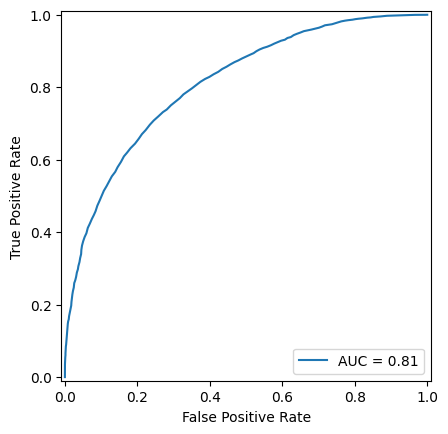

lr roc curve:


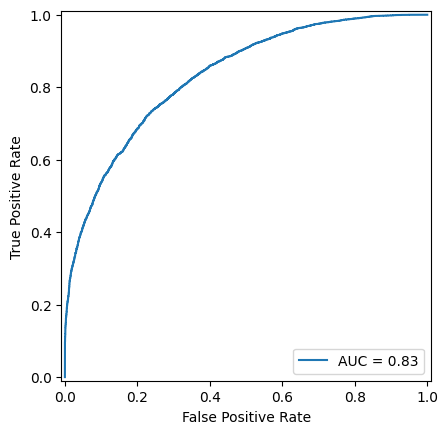

ann roc curve:


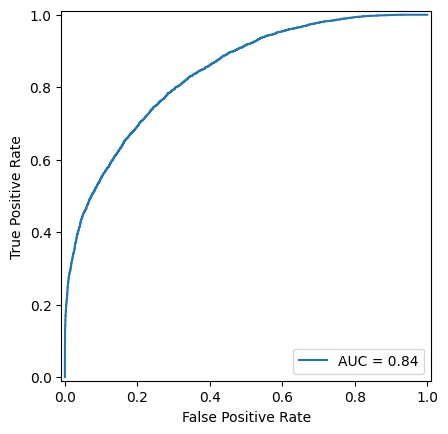

In [33]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
X_train, X_valid, Y_train, Y_valid = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=420)
pca = PCA()
sc = StandardScaler()
X_train = pca.fit_transform(sc.fit_transform(X_train))
X_valid = pca.transform(sc.transform(X_valid))

knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train, Y_train)
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, Y_train)
ann = MLPClassifier(hidden_layer_sizes=hidden_layer_t, learning_rate='adaptive', max_iter=1000, learning_rate_init=learning_rate_init_t, alpha=alpha)
ann.fit(X_train, Y_train)

knn_pred_proba = knn.predict_proba(X_valid)
lr_pred_proba = lr.predict_proba(X_valid)
ann_pred_proba = ann.predict_proba(X_valid)


print("knn roc curve:")
fpr, tpr, _ = roc_curve(Y_valid, knn_pred_proba[:,1])
roc_auc = auc(fpr, tpr)

roc_display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc)
roc_display.plot()
plt.show()


print("lr roc curve:")
fpr, tpr, _ = roc_curve(Y_valid, lr_pred_proba[:, 1])
roc_auc = auc(fpr, tpr)

roc_display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc)
roc_display.plot()
plt.show()


print("ann roc curve:")
fpr, tpr, _ = roc_curve(Y_valid, ann_pred_proba[:,1])
roc_auc = auc(fpr, tpr)

roc_display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc)
roc_display.plot()
plt.show()

knn:
0.7292785234899329 0.7356834975369458


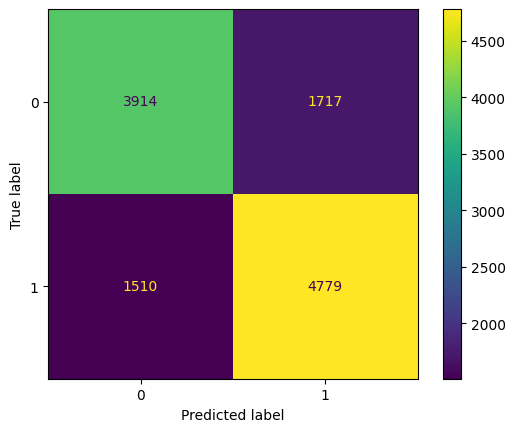

lr:
0.7439597315436242 0.7552436524207539


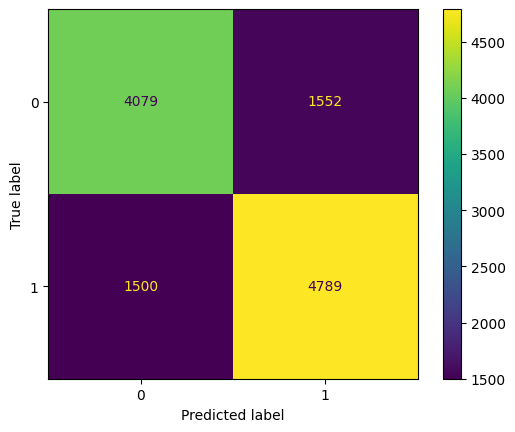

ann:
0.7493288590604027 0.7657382064079858


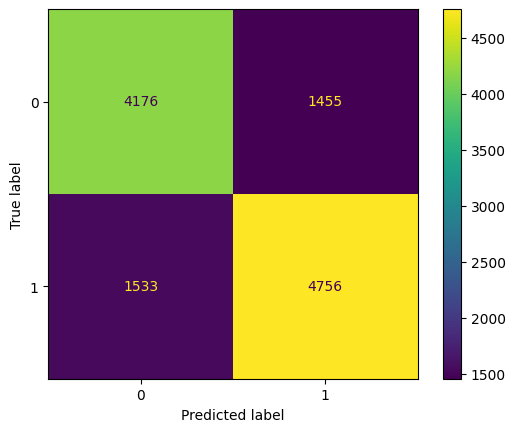

In [34]:
knn_pred = knn.predict(X_valid)
lr_pred = lr.predict(X_valid)
ann_pred = ann.predict(X_valid)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score

print("knn:")
acc = accuracy_score(Y_valid, knn_pred)
prec = precision_score(Y_valid, knn_pred)
print(acc, prec)

cm = confusion_matrix(Y_valid, knn_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

print("lr:")
acc = accuracy_score(Y_valid, lr_pred)
prec = precision_score(Y_valid, lr_pred)
print(acc, prec)

cm = confusion_matrix(Y_valid, lr_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

print("ann:")
acc = accuracy_score(Y_valid, ann_pred)
prec = precision_score(Y_valid, ann_pred)
print(acc, prec)

cm = confusion_matrix(Y_valid, ann_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [35]:
X_test = pd.read_csv('./data/test_processed.csv')
y_test = X_test['Attrition']
X_test = X_test.drop('Attrition', axis=1)
X_test = pca.transform(sc.transform(X_test))

ann.predict(X_test)
acc = accuracy_score(y_test, ann.predict(X_test))
prec = precision_score(y_test, ann.predict(X_test))

print(acc, prec)

0.7525503355704698 0.7685982269047925
